In [10]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
import PhysicalConstants.CODATA2018: c_0
using Unitful
using Printf
using HDF5

In [8]:
function load_masks(filename, Nfiles)
    masks = []

    h5open(filename, "r") do file
        for i = 1:Nfiles
            push!(masks, convert(Matrix{Int}, read(file["image_"* @sprintf("%04d", i)])))
        end
    end
    return masks
end

load_masks (generic function with 1 method)

In [4]:
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
#@load "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe;

# Atomic data
Γ = 2.02e8 # In Hz
λ = 421e-9 # In m
ω0 = 2π*ustrip(c_0)/λ
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

In [12]:
masks = load_masks("my_masked_images.h5", 5)

5-element Vector{Any}:
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]

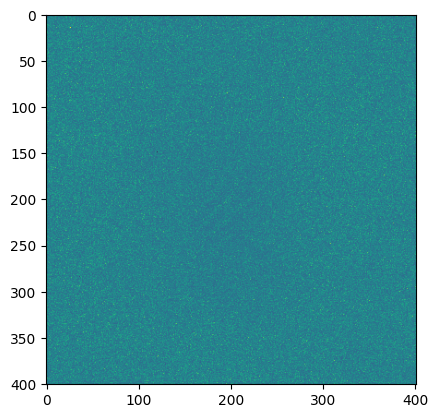

PyObject <matplotlib.image.AxesImage object at 0x000002CBD512C690>

In [15]:
imshow(Imgs_atoms_crop_ds[1, 1, :, :])

In [16]:
size(masks)

(5,)

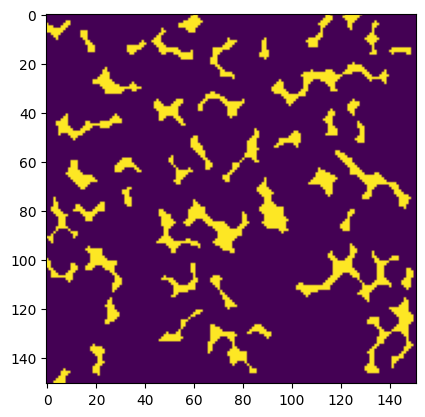

PyObject <matplotlib.image.AxesImage object at 0x000002CB95D0D550>

In [13]:
imshow(masks[1])